<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/MachineLearning-Doc/blob/main/2026_Canny_Edge_Detector_SE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bài Lab: Canny Edge Detector

## Mục tiêu
Triển khai thuật toán Canny Edge Detector phát hiện biên trong Thị giác máy tính. Thuật toán bao gồm ba giai đoạn chính:

1. **Tính gradient mịn (smoothed gradients).**
2. **Loại bỏ cực đại không tối ưu (Non-maximal Suppression).**
3. **Ngưỡng hóa phân cấp (Hysteresis Thresholding).**

Sử dụng Python cùng các thư viện như NumPy, SciPy, và Matplotlib để xử lý ảnh và trực quan hóa kết quả.


```
pip install scikit-image
```

In [34]:
import numpy as np
import skimage
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy import ndimage
from scipy.ndimage.filters import convolve

/tmp/ipykernel_2572/1301909518.py:6: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import convolve


In [35]:
def read_image(input_img):
    # Danh sách các định dạng
    supported_formats = ['.bmp', '.jpg', '.png']

    # Kiểm tra định dạng
    for fmt in supported_formats:
        input_path = os.path.join('/content', input_img + fmt)
        if os.path.exists(input_path):
            with open(input_path, 'rb') as f:
                # Đọc dữ liệu ảnh
                image_data = f.read()
                # Xử lý ảnh tùy thuộc vào định dạng
                if fmt == '.bmp':
                    print("Đọc ảnh BMP")
                elif fmt == '.jpg':
                    print("Đọc ảnh JPG")
                elif fmt == '.png':
                    print("Đọc ảnh PNG")
                return input_path  # Trả về đường dẫn ảnh
    print("Không đọc được ảnh.")
    return None

## Phần 1: Tính Gradient (Smoothed Gradients)

### Mô tả
Mục tiêu là giảm nhiễu và tính toán gradient của ảnh để phát hiện các điểm có sự thay đổi cường độ lớn (cạnh).

### Yêu cầu

1. **Chuyển ảnh màu sang thang độ xám:**
   - Nếu ảnh đầu vào là ảnh RGB, chuyển sang thang độ xám để đơn giản hóa xử lý.

2. **Làm mịn ảnh bằng bộ lọc Gaussian:**
   - Áp dụng tích chập với Gaussian $(𝜎 = 1)$ để giảm nhiễu.

3. **Tính gradient theo hướng x và y:**
   - Dùng toán tử Sobel để tính 𝐼ₓ (gradient ngang) và 𝐼ᵧ (gradient dọc).

4. **Tính độ lớn và hướng gradient:**
   - Độ lớn gradient: $𝐹 = √(𝐼ₓ² + 𝐼ᵧ²)$.
   - Hướng gradient: $𝐷 = arctan(𝐼ᵧ / 𝐼ₓ)$.

### Công thức toán học

1. **Gaussian Kernel $(𝜎 = 1)$:**
   $$
   G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}
   $$
   Ma trận 3x3 xấp xỉ:
   $$
   G = \begin{bmatrix}
   0.1019 & 0.1154 & 0.1019 \\
   0.1154 & 0.1308 & 0.1154 \\
   0.1019 & 0.1154 & 0.1019
   \end{bmatrix}
   $$

2. **Toán tử Sobel:**
   $$
   Sₓ = \begin{bmatrix}
   -1 & 0 & 1 \\
   -2 & 0 & 2 \\
   -1 & 0 & 1
   \end{bmatrix}, \quad Sᵧ = \begin{bmatrix}
   1 & 2 & 1 \\
   0 & 0 & 0 \\
   -1 & -2 & -1
   \end{bmatrix}
   $$

3. **Gradient:**
   $$
   Iₓ = I * Sₓ, \quad Iᵧ = I * Sᵧ
   $$
   $$
   F = \sqrt{Iₓ² + Iᵧ²}, \quad D = \arctan{\left(\frac{Iᵧ}{Iₓ}\right)}
   $$


## Chuyển ảnh xám và tính Gradient

```
Hàm rgb2gray sử dụng công thức Luminance giúp cân bằng độ nhạy sáng của mắt người đối với 3 kênh màu R, G, B.

Hàm convolveWithGaussianDerivative sử dụng cặp ma trận Sobel $S_x$ và $S_y$ để dò tìm các đường biên tương phản theo hướng ngang và dọc.
```


In [36]:
def rgb2gray(img):
    """
    Chuyển đổi ảnh RGB sang xám theo công thức chuẩn Luminance:
    Y = 0.2989*R + 0.5870*G + 0.1140*B
    """
    return (np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])).astype('float32')

def convolveWithGaussianDerivative(img):
    """
    Tính gradient ngang (Ix) và dọc (Iy) bằng ma trận Sobel,
    và góc hướng gradient (theta_angle).
    """
    # Ma trận Sobel dò cạnh
    sobel_x = np.asarray([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.asarray([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)

    # Tích chập ảnh (Convolution) với ma trận Sobel
    Ix = convolve(img, sobel_x)  # Đạo hàm theo trục X
    Iy = convolve(img, sobel_y)  # Đạo hàm theo trục Y

    # Tính hướng biến thiên của cường độ sáng (Góc theta từ -pi đến pi)
    theta_angle = np.arctan2(Iy, Ix)

    return Ix, Iy, theta_angle

print("Đã khởi tạo các hàm xử lý xong ảnh.")

Đã khởi tạo các hàm xử lý xong ảnh.


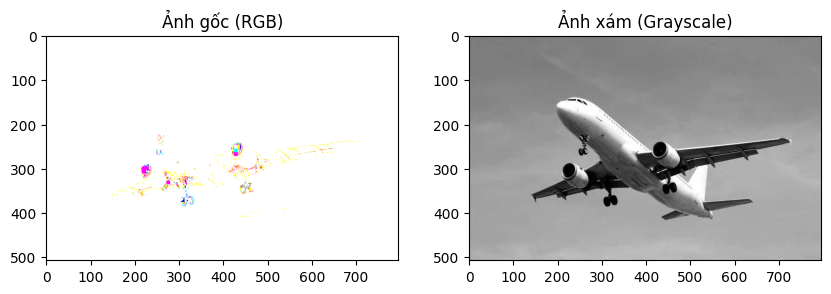

In [37]:
input_path = "/content/Airplane.jpg"

# 1. Đọc ảnh từ đường dẫn
img = mpimg.imread(input_path).astype('float32')

# 2. Chuyển sang thang độ xám
img_gray = rgb2gray(img)

# 3. Trực quan hóa ảnh gốc và ảnh xám để so sánh
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img)
ax[0].set_title("Ảnh gốc (RGB)")

ax[1].imshow(img_gray, cmap='gray')
ax[1].set_title("Ảnh xám (Grayscale)")

plt.show()

### Tính toán và trực quan hóa các thành phần Gradient

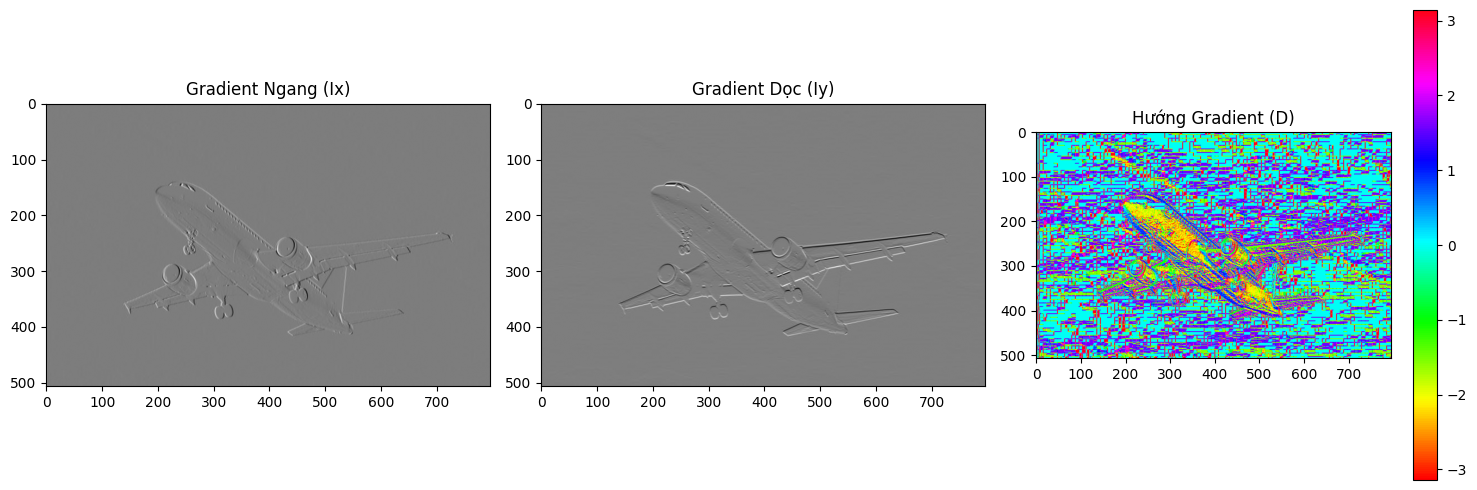

In [38]:
import os
# Gọi hàm tính toán
Ix, Iy, theta_angle = convolveWithGaussianDerivative(img_gray)

# Lưu ảnh Grayscale lại vào thư mục hệ thống
output_dir = 'Results/canny_edge/'
os.makedirs(output_dir, exist_ok=True)
input_img_name = os.path.splitext(os.path.basename(input_path))[0]
plt.imsave(os.path.join(output_dir, input_img_name + '_luminance.jpg'), img_gray, cmap='gray')

# Trực quan hóa 3 thành phần đầu ra
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Hiển thị Gradient Ngang
axes[0].imshow(Ix, cmap='gray')
axes[0].set_title('Gradient Ngang (Ix)')

# Hiển thị Gradient Dọc
axes[1].imshow(Iy, cmap='gray')
axes[1].set_title('Gradient Dọc (Iy)')

# Hiển thị Hướng Gradient
# Sử dụng cmap='hsv' để đổi góc lượng giác [-pi, pi] thành các màu sắc trực quan khác nhau
pos = axes[2].imshow(theta_angle, cmap='hsv')
axes[2].set_title('Hướng Gradient (D)')
fig.colorbar(pos, ax=axes[2])

plt.tight_layout()
plt.show()

### tính Độ lớn Gradient và chuẩn hóa hiển thị

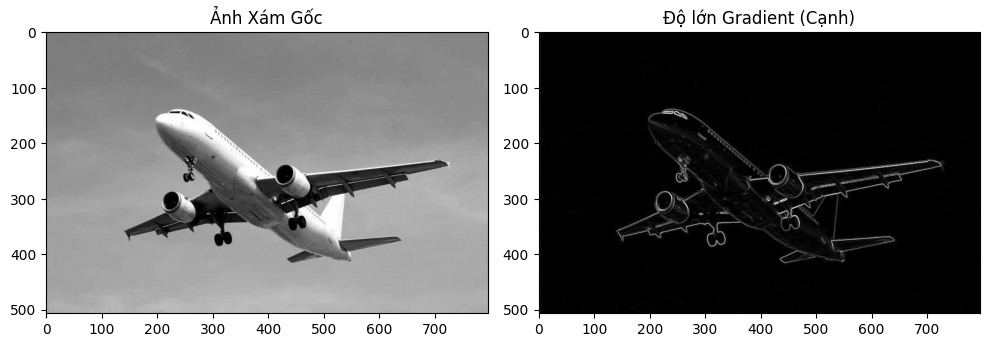

In [39]:
# 1. Tính độ lớn Gradient theo công thức Pitago: G = sqrt(Ix^2 + Iy^2)
gradient_magnitude = np.sqrt(Ix**2 + Iy**2)

# 2. Chuẩn hóa ma trận điểm ảnh về khoảng [0, 255] để lưu trữ hoặc [0.0, 1.0] để hiển thị
# Bước này giúp các đường biên sáng rõ và nổi bật hơn trên nền đen
if gradient_magnitude.max() != 0:
    gradient_magnitude_normalized = gradient_magnitude / gradient_magnitude.max()
else:
    gradient_magnitude_normalized = gradient_magnitude

# 3. Lưu ảnh kết quả tách cạnh vào thư mục
plt.imsave(os.path.join(output_dir, input_img_name + '_gradient_magnitude.jpg'),
           gradient_magnitude_normalized, cmap='gray')

# 4. Trực quan hóa kết quả so sánh giữa ảnh xám gốc và ảnh cạnh cuối cùng
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Ảnh Xám Gốc')
axes[1].imshow(gradient_magnitude_normalized, cmap='gray')
axes[1].set_title('Độ lớn Gradient (Cạnh)')

plt.tight_layout()
plt.show()

# Sử dụng OpenCV để tính toán Gradient và Magnitude

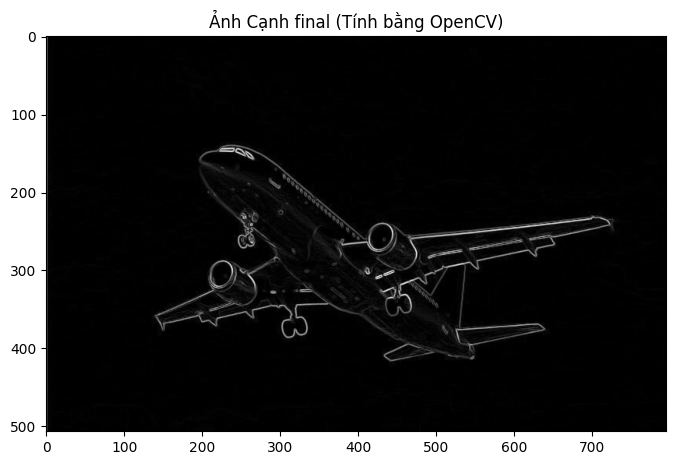

In [40]:
import cv2

# 1. Đọc ảnh trực tiếp ở dạng ảnh xám (Grayscale) bằng OpenCV
# Cờ cv2.IMREAD_GRAYSCALE tự động chuyển ảnh thành xám và giữ nguyên giá trị [0, 255]
img_gray_cv = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)

# 2. Tính Gradient Ix và Iy bằng toán tử Sobel tích hợp sẵn
# cv2.CV_32F giúp giữ độ chính xác số thực (float), tránh mất mát dữ liệu khi đạo hàm
Ix_cv = cv2.Sobel(img_gray_cv, cv2.CV_32F, 1, 0, ksize=3) # 1, 0 là đạo hàm theo X
Iy_cv = cv2.Sobel(img_gray_cv, cv2.CV_32F, 0, 1, ksize=3) # 0, 1 là đạo hàm theo Y

# 3. Gộp Ix, Iy để tính Độ lớn Gradient (Magnitude) bằng hàm chuyên dụng
# Hàm này tự động tính sqrt(Ix^2 + Iy^2) cho toàn bộ ma trận ảnh vô cùng nhanh
gradient_magnitude_cv = cv2.magnitude(Ix_cv, Iy_cv)

# Chuẩn hóa giá trị về khoảng [0, 255] để hiển thị
gradient_magnitude_cv = cv2.normalize(gradient_magnitude_cv, None, 0, 255, cv2.NORM_MINMAX)
gradient_magnitude_cv = np.uint8(gradient_magnitude_cv)

# 4. Trực quan kết quả
plt.figure(figsize=(8, 8))
plt.imshow(gradient_magnitude_cv, cmap='gray')
plt.title("Ảnh Cạnh final (Tính bằng OpenCV)")
plt.show()

## Phần 2: Non-maximal Suppression

### Mô tả
Phần này yêu cầu làm mỏng các cạnh bằng cách loại bỏ các điểm không phải cực đại theo hướng gradient, đảm bảo cạnh chỉ dày 1 pixel.

### Yêu cầu

1. **Xác định hướng gần đúng 𝐷∗:**
   - Góc 𝐷 được lượng tử hóa thành 4 hướng:
     
     0, π/4, π/2, 3π/4
      
     (tương ứng 0°, 45°, 90°,135°).

2. **So sánh độ lớn gradient:**
   - Với mỗi pixel, so sánh 𝐹[y,x] với hai láng giềng theo hướng 𝐷∗.
   - Nếu 𝐹[y,x] không lớn nhất, đặt 𝐼[y,x] = 0; ngược lại, giữ 𝐼[y,x] = 𝐹[y,x].

### Công thức

1. **Hướng gần đúng 𝐷∗:**
   - Nếu 𝐷 ∈ [0°, 22.5°) ∪ [157.5°, 180°) → 𝐷∗ = 0.
   - Nếu 𝐷 ∈ [22.5°, 67.5°) → 𝐷∗ = π/4.
   - Nếu 𝐷 ∈ [67.5°, 112.5°) → 𝐷∗ = π/2.
   - Nếu 𝐷 ∈ [112.5°, 157.5°) → 𝐷∗ = 3π/4.

2. **So sánh theo hướng:**
   - Ví dụ: Nếu 𝐷∗ = 0, so sánh 𝐹[y,x] với 𝐹[y,x+1] và 𝐹[y,x−1].


Đọc ảnh JPG


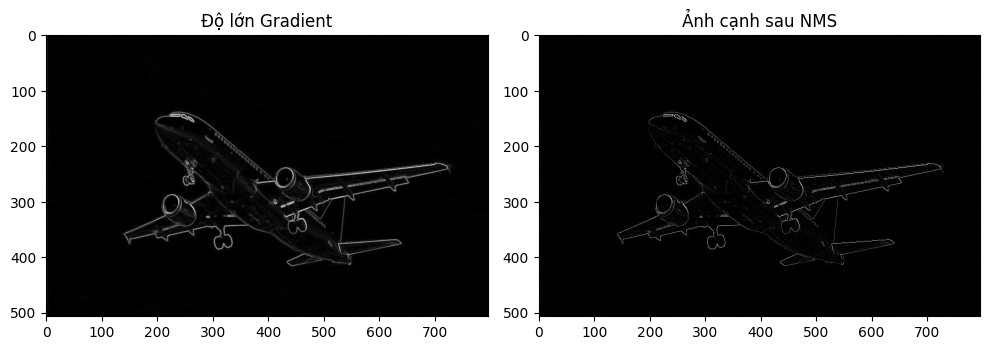

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy import ndimage

def Non_maximal_Suppression(Gradient, theta_angle):
    """
    Thực hiện Non-Maximal Suppression để làm mỏng các cạnh.
    """
    M, N = Gradient.shape
    output = np.zeros((M, N), dtype=np.float32) # Ảnh cạnh mỏng
    angle = np.degrees(theta_angle)  # Chuyển từ radian sang độ
    for i in range(1, M-1):
        for j in range(1, N-1):
            q = 255
            r = 255

            if angle[i, j] < 0:
                angle[i, j] += 180  # Chuẩn hóa góc về [0, 180]

            # Xác định hướng gần đúng D*
            # Hướng 0 độ (ngang)
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = Gradient[i, j+1]
                r = Gradient[i, j-1]
            # Hướng 45 độ (chéo lên phải)
            elif (22.5 <= angle[i,j] < 67.5):
                q = Gradient[i+1, j-1]
                r = Gradient[i-1, j+1]
            # Hướng 90 độ (dọc)
            elif (67.5 <= angle[i,j] < 112.5):
                q = Gradient[i+1, j]
                r = Gradient[i-1, j]
            # Hướng 135 độ (chéo lên trái)
            elif (112.5 <= angle[i,j] < 157.5):
                q = Gradient[i-1, j-1]
                r = Gradient[i+1, j+1]

            # So sánh và giữ cực đại
            if (Gradient[i,j] >= q) and (Gradient[i,j] >= r):
                output[i,j] = Gradient[i,j]
            else:
                output[i,j] = 0.0
    return output

# Đọc ảnh đầu vào và xử lý
def process_image(input_img_name):
    """
    Đọc ảnh đầu vào, chuyển sang thang độ xám, tính gradient, áp dụng NMS và lưu kết quả.
    """

    # Đọc ảnh
    input_path = read_image(input_img_name)
    if input_path is None:
        raise FileNotFoundError(f"Không tìm thấy ảnh với tên: {input_img_name}")

    # Đọc và chuẩn hóa ảnh
    img = mpimg.imread(input_path).astype('float32')
    img_gray = rgb2gray(img)  # Chuyển sang thang độ xám

    # Tính gradient và hướng gradient
    Ix, Iy, theta_angle = convolveWithGaussianDerivative(img_gray)

    # Tính độ lớn gradient
    Gradient = np.sqrt(Ix**2 + Iy**2)  # Độ lớn gradient
    if Gradient.max() != 0:
        Gradient = Gradient / Gradient.max()  # Chuẩn hóa
    else:
        Gradient = Gradient

    # Lưu ảnh gradient magnitude
    output_dir = 'Results/canny_edge/'
    os.makedirs(output_dir, exist_ok=True)  # Tạo thư mục nếu chưa có
    plt.imsave(os.path.join(output_dir, input_img_name + '_gradient_magnitude.jpg'), Gradient, cmap='gray')

    # Áp dụng Non-Maximal Suppression
    thinned_edge_image = Non_maximal_Suppression(Gradient, theta_angle)

    # Lưu ảnh cạnh mỏng
    plt.imsave(os.path.join(output_dir, input_img_name + '_thinned_edge.jpg'), thinned_edge_image, cmap='gray')

    # Hiển thị kết quả
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(Gradient, cmap='gray')
    axes[0].set_title('Độ lớn Gradient')
    axes[1].imshow(thinned_edge_image, cmap='gray')
    axes[1].set_title('Ảnh cạnh sau NMS')

    plt.tight_layout()
    plt.show()

# Chạy hàm xử lý với tên ảnh đầu vào
input_img = 'Airplane'  # tên ảnh không cần phần mở rộng
process_image(input_img)

## Phần 3: Hysteresis Thresholding

### Mô tả
Ở bước này sẽ thực hiện phân loại các pixel thành cạnh mạnh, cạnh yếu, hoặc không phải cạnh. Sau đó, kết nối các cạnh yếu với cạnh mạnh để tạo ra biên cuối cùng.

Có 3 kỹ thuật cốt lõi cuối cùng nhằm tinh lọc cạnh biên:

- Non-Maximal Suppression (NMS): Làm mảnh các đường biên (chỉ giữ lại điểm cực đại cục bộ dọc theo hướng gradient).

- Double Thresholding (Ngưỡng kép): Phân loại điểm ảnh thành 3 loại: Cạnh mạnh (chắc chắn là cạnh), Cạnh yếu (đang nghi ngờ), và Không phải cạnh.

- Edge Tracking by Hysteresis (Lọc cạnh bằng Hysteresis): Cứu các cạnh yếu nếu chúng kết nối với cạnh mạnh thông qua lân cận 8 ô.

### Yêu cầu

1. **Áp dụng ngưỡng kép:**
   - 𝑇ₗₒw (ngưỡng thấp) và 𝑇ₕᵢgh (ngưỡng cao).
   - Nếu 𝐹 < 𝑇ₗₒw: Không phải cạnh (𝐼[y,x] = 0).
   - Nếu 𝐹 ≥ 𝑇ₕᵢgh: Cạnh mạnh (𝐼[y,x] = 1).
   - Nếu 𝑇ₗₒw ≤ 𝐹 < 𝑇ₕᵢgh: Cạnh yếu (𝐼[y,x] = 0.5).

2. **Kết nối cạnh yếu với cạnh mạnh:**
   - Duyệt qua 8 neighbourhood của các pixel mạnh. Nếu có cạnh yếu liền kề, chuyển thành cạnh mạnh.

### Công thức toán học

1. **Ngưỡng hóa:**
   $$
   I[y,x] =
   \begin{cases}
   0 & \text{nếu } F[y,x] < T_{low} \\
   0.5 & \text{nếu } T_{low} \leq F[y,x] < T_{high} \\
   1 & \text{nếu } F[y,x] \geq T_{high}
   \end{cases}
   $$

2. **Kiểm tra 8 neighbourhood:**
   Các hướng:
   $$
   (0,1), (0,-1), (-1,0), (1,0), (-1,-1), (1,-1), (-1,1), (1,1)
   $$


## Làm mảnh cạnh (Non-Maximal Suppression)

Trước khi phân ngưỡng, ta cần chuyển đổi hướng gradient $\theta$ sang 4 hướng cơ bản ($0^\circ, 45^\circ, 90^\circ, 135^\circ$) để so sánh pixel hiện tại với các pixel lân cận theo hướng vuông góc với cạnh.

In [42]:
# Định nghĩa hàm Non-Maximal Suppression (NMS)
import numpy as np

def Non_maximal_Suppression(img, theta):
    """
    Làm mảnh cạnh bằng cách giữ lại các điểm có độ lớn gradient
    lớn nhất so với 2 điểm lân cận theo hướng gradient.
    """
    M, N = img.shape
    Z = np.zeros((M, N), dtype=np.float32)

    # Chuyển đổi radian sang độ để dễ phân loại hướng
    angle = np.degrees(theta)

    for i in range(1, M-1):
        for j in range(1, N-1):
            q = 255
            r = 255

            if angle[i,j] < 0:
                angle[i,j] += 180

            # Hướng 0 độ (Biên dọc - kiểm tra lân cận trái/phải)
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = img[i, j+1]
                r = img[i, j-1]
            # Hướng 45 độ (Đường chéo phải)
            elif (22.5 <= angle[i,j] < 67.5):
                q = img[i+1, j-1]
                r = img[i-1, j+1]
            # Hướng 90 độ (Biên ngang - kiểm tra lân cận trên/dưới)
            elif (67.5 <= angle[i,j] < 112.5):
                q = img[i+1, j]
                r = img[i-1, j]
            # Hướng 135 độ (Đường chéo trái)
            elif (112.5 <= angle[i,j] < 157.5):
                q = img[i-1, j-1]
                r = img[i+1, j+1]

            # Giữ lại nếu là cực đại cục bộ
            if (img[i,j] >= q) and (img[i,j] >= r):
                Z[i,j] = img[i,j]
            else:
                Z[i,j] = 0

    return Z

print("Đã khởi tạo hàm Non-Maximal Suppression ok")

Đã khởi tạo hàm Non-Maximal Suppression ok


## Định nghĩa các hàm phân ngưỡng (Double Threshold & Hysteresis)

In [43]:
# Định nghĩa hàm Ngưỡng kép và Hysteresis Lọc Cạnh

def threshold(img, low_Th, high_Th):
    """
    Phân loại các điểm ảnh thành cạnh mạnh (1.0), cạnh yếu (0.5) và không phải cạnh (0.0).
    """
    output = np.zeros(img.shape, dtype='float32')
    output[np.where(img < low_Th)] = 0.0                      # Không phải cạnh
    output[np.where(img >= high_Th)] = 1.0                    # Cạnh mạnh
    output[np.where((img >= low_Th) & (img < high_Th))] = 0.5  # Cạnh yếu
    return output

def check_8_neighbourhood(img, row, col):
    """
    Kiểm tra xem pixel nghi ngờ (cạnh yếu) có chạm vào bất kỳ cạnh mạnh nào trong 8 ô xung quanh không.
    """
    dirs = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
    for dr, dc in dirs:
        if img[row + dr, col + dc] == 1.0:  # Phát hiện có điểm cạnh mạnh kế bên
                return True
    return False

def perfom_hysteresis(img):
    """
    Liên kết các cạnh yếu với cạnh mạnh nếu nằm trong vùng lân cận 8 ô.
    Nếu cô lập, loại bỏ luôn!
    """
    _img = np.copy(img)
    dim1, dim2 = img.shape
    for i in range(1, dim1-1):
        for j in range(1, dim2-1):
            if _img[i, j] == 0.5:
                if check_8_neighbourhood(img, i, j):
                    _img[i, j] = 1.0  # Được cứu -> Trở thành cạnh mạnh
                else:
                    _img[i, j] = 0.0  # Bị loại bỏ -> Chuyển về nền đen
    return _img

print("Đã khởi tạo các hàm xử lý logic biên cạnh!")

Đã khởi tạo các hàm xử lý logic biên cạnh!


## Đọc ảnh và Tính toán ma trận Gradient ban đầu

In [44]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy import ndimage

# Các hàm bổ trợ từ Bài tập 1
def rgb2gray(img):
    return (np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])).astype('float32')

def convolveWithGaussianDerivative(img):
    sobel_x = np.asarray([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.asarray([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)
    Ix = convolve(img, sobel_x)
    Iy = convolve(img, sobel_y)
    theta_angle = np.arctan2(Iy, Ix)
    return Ix, Iy, theta_angle

# Đọc ảnh đầu vào và xử lý
input_path = "/content/Airplane.jpg"

if not os.path.exists(input_path):
    raise FileNotFoundError(f"Không tìm thấy ảnh tại đường dẫn: {input_path}")

# Đọc và chuẩn hóa ảnh
img = mpimg.imread(input_path).astype('float32')
img_gray = rgb2gray(img)

# Tính toán các thành phần cần thiết
Ix, Iy, theta_angle = convolveWithGaussianDerivative(img_gray)
Gradient = np.sqrt(Ix**2 + Iy**2)
if Gradient.max() != 0:
    Gradient = Gradient / Gradient.max() # Chuẩn hóa về [0, 1]
else:
    Gradient = Gradient

print("Ảnh đã được nạp và tính toán Gradient")

Ảnh đã được nạp và tính toán Gradient


## CHạy NMS và Phân ngưỡng kép (Double Threshold)

NMS để làm mảnh các nét biên dày thành các nét thanh mảnh có độ dày chỉ 1 pixel, sau đó phân tách vùng dựa trên hai mức ngưỡng $0.1$ và $0.25$.

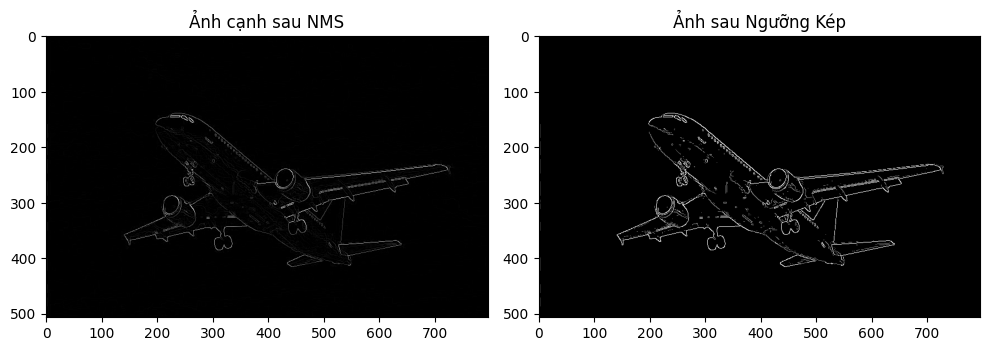

In [45]:
# Áp dụng NMS và Ngưỡng hóa (Thresholding)

# 1. Làm mảnh đường biên (Non-Maximal Suppression)
thinned_edge_image = Non_maximal_Suppression(Gradient, theta_angle)

# 2. Định nghĩa ngưỡng kép và tiến hành phân loại
low_Th, high_Th = 0.1, 0.25
thresholded_img = threshold(thinned_edge_image, low_Th, high_Th)

# 3. Tạo thư mục và lưu ảnh phân ngưỡng
output_dir = 'Results/canny_edge/'
os.makedirs(output_dir, exist_ok=True)
plt.imsave(os.path.join(output_dir, 'Plane_threshold.jpg'), thresholded_img, cmap='gray')

# 4. Trực quan hóa kết quả sau khi phân ngưỡng
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(thinned_edge_image, cmap='gray')
axes[0].set_title('Ảnh cạnh sau NMS')
axes[1].imshow(thresholded_img, cmap='gray')
axes[1].set_title('Ảnh sau Ngưỡng Kép')

plt.tight_layout()
plt.show()

## Chạy Hysteresis và Trực quan hóa so sánh kết quả final

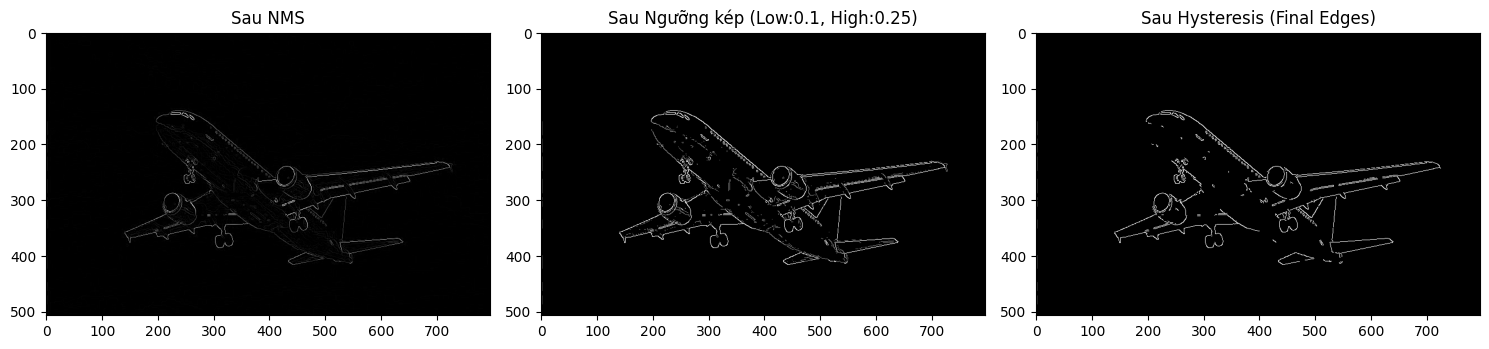

In [46]:
# Sử dụng Hysteresis lọc cạnh cô lập và Xuất báo cáo trực quan

# 1. Thực hiện Hysteresis kết nối biên
hystersis_img = perfom_hysteresis(thresholded_img)

# 2. Lưu ảnh kết quả final sau Hysteresis
plt.imsave(os.path.join(output_dir, 'Plane_final_edges.jpg'), hystersis_img, cmap='gray')

# 3. Vẽ biểu đồ so sánh 3 trạng thái để sinh viên dễ phân tích lý thuyết
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(thinned_edge_image, cmap='gray')
axes[0].set_title('Sau NMS')
axes[1].imshow(thresholded_img, cmap='gray')
axes[1].set_title(f'Sau Ngưỡng kép (Low:{low_Th}, High:{high_Th})')
axes[2].imshow(hystersis_img, cmap='gray')
axes[2].set_title('Sau Hysteresis (Final Edges)')

plt.tight_layout()
plt.show()

Nhận xét: các đường màu xám (cạnh yếu) ở ngoài nền trời biến mất hoàn toàn, trong khi các nét màu xám bám dọc thân máy bay lại được chuyển thành màu trắng (cạnh mạnh)? Đó chính là sức mạnh của bộ lọc kết nối Hysteresis

# Sử dụng hàm cv2.Canny trong thư viện Open CV

Text(0.5, 1.0, 'Canny Edges bằng OpenCV')

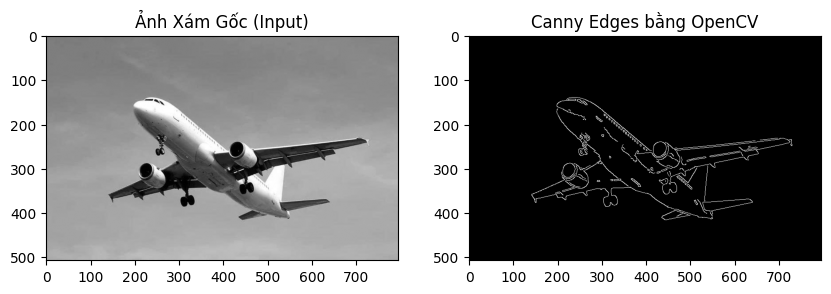

In [47]:
import cv2
import matplotlib.pyplot as plt

# 1. Đọc ảnh gốc trực tiếp dưới dạng ảnh xám (Grayscale)
input_path = "/content/Airplane.jpg"
img_gray = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)


# 2. Áp dụng làm mịn ảnh bằng Gaussian Blur để khử nhiễu trước
# Bước này giúp hướng Gradient không bị lệch, tránh mất nét khi chạy Hysteresis
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# 3. Gọi hàm Canny tích hợp toàn bộ các bước: Sobel, NMS, Double Threshold, Hysteresis
# ảnh đã làm mịn, Ngưỡng thấp (low_threshold), Ngưỡng cao (high_threshold)
# điều chỉnh lại ngưỡng 50 và 150 (trên thang 255) để lấy được các nét mảnh ở đuôi máy bay
cv2_edges = cv2.Canny(img_blur, 50, 150)

# 4. Trực quan hóa so sánh ảnh xám và kết quả tách cạnh hoàn hảo của OpenCV
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Ảnh Xám Gốc (Input)")

axes[1].imshow(cv2_edges, cmap='gray')
axes[1].set_title("Canny Edges bằng OpenCV")

# Nhận xét và Phân tích kết quả Lab Canny Edge Detector

## 1. Ý nghĩa cốt lõi của từng bước xử lý

Thuật toán Canny Edge Detector là một quy trình nhiều bước nhằm tối ưu hóa việc phát hiện biên.

*   **Gaussian Blur:** Làm mịn ảnh, loại bỏ nhiễu để tránh các cạnh giả và đảm bảo độ chính xác của gradient, dù có thể làm mờ nhẹ chi tiết.
*   **Sobel Operator:** Tính toán độ lớn và hướng gradient, xác định các vùng có sự thay đổi cường độ sáng mạnh mẽ, là nền tảng cho việc xác định vị trí cạnh.
*   **Non-Maximal Suppression (NMS):** Làm mỏng các cạnh, loại bỏ các pixel không phải cực đại cục bộ theo hướng gradient, giúp đường biên sắc nét và có độ dày 1 pixel.
*   **Hysteresis Thresholding:** Liên kết các cạnh yếu với cạnh mạnh lân cận để tạo thành đường biên liên tục, đồng thời loại bỏ nhiễu cô lập, đảm bảo độ bền vững và chính xác của biên.

## 2. Ảnh hưởng của các tham số

Việc tinh chỉnh tham số ảnh hưởng trực tiếp đến chất lượng phát hiện biên:

*   **Sigma ($\sigma$) trong Gaussian Blur:**
    *   **$\sigma$ nhỏ:** Giữ nhiều chi tiết nhưng cũng giữ nhiều nhiễu, có thể dẫn đến nhiều cạnh giả.
    *   **$\sigma$ lớn:** Khử nhiễu tốt nhưng có thể làm mờ các cạnh tinh tế, làm mất thông tin hoặc dịch chuyển vị trí biên.
*   **Ngưỡng thấp ($T_{low}$) và ngưỡng cao ($T_{high}$) trong Hysteresis Thresholding:**
    *   **$T_{high}$:** Xác định các cạnh mạnh 'chắc chắn'. Giá trị cao có thể bỏ sót cạnh thực.
    *   **$T_{low}$:** Xác định giới hạn dưới cho cạnh yếu có thể được 'cứu'. Giá trị thấp dễ giữ nhiễu, giá trị cao dễ làm đứt gãy biên.
    *   **Tỷ lệ $T_{low}/T_{high}$ (thường 1:2 hoặc 1:3):** Ảnh hưởng đến khả năng liên kết của cạnh yếu.

## 3. So sánh thuật toán tự cài đặt và `cv2.Canny()` của OpenCV

*   **Chất lượng đường biên:**
    *   **Tự cài đặt:** Phụ thuộc vào độ chính xác từng hàm và tinh chỉnh tham số, có thể không mượt mà bằng.
    *   **`cv2.Canny()`:** Cung cấp chất lượng biên vượt trội (mượt mà, liên tục, chính xác) do được tối ưu hóa và phát triển chuyên sâu.
*   **Tốc độ xử lý:**
    *   **Tự cài đặt:** Chậm hơn đáng kể, đặc biệt với ảnh lớn hoặc các vòng lặp Python thuần túy.
    *   **`cv2.Canny()`:** Nhanh vượt trội nhờ được viết bằng C/C++ và tối ưu hóa phần cứng, phù hợp cho ứng dụng thời gian thực.
*   **Nhận xét chung:** `cv2.Canny()` là lựa chọn hàng đầu cho thực tế. Tuy nhiên, tự cài đặt là bài học giá trị để hiểu sâu nguyên lý Canny.

## 4. Giải thích hiện tượng: Cạnh yếu thân máy bay và nhiễu cô lập nền trời

Hiện tượng này minh họa hiệu quả của **Hysteresis Thresholding** trong việc sử dụng thông tin ngữ cảnh:

*   **Cạnh yếu bám dọc thân máy bay được giữ lại:** Các đường nét này, dù yếu, là một phần của cấu trúc vật thể lớn. Sau Ngưỡng kép, chúng là 'cạnh yếu'. Do chúng nằm liền kề và kết nối với các 'cạnh mạnh' khác trên thân máy bay, bước Hysteresis sẽ 'cứu' và chuyển chúng thành cạnh mạnh, đảm bảo tính liên tục của đường biên.
*   **Các điểm nhiễu cô lập ở nền trời bị loại bỏ:** Các nhiễu nhỏ ở nền trời có thể tạo ra 'cạnh yếu'. Tuy nhiên, chúng thường cô lập và không kết nối với bất kỳ 'cạnh mạnh' nào. Khi Hysteresis kiểm tra, chúng không đủ điều kiện để được 'cứu' và sẽ bị loại bỏ hoàn toàn (đặt về 0.0), giúp làm sạch ảnh khỏi nhiễu giả.

Tổng kết, Hysteresis Thresholding là cơ chế thông minh giúp Canny phát hiện biên mạnh mẽ và chính xác bằng cách phân biệt giữa cạnh thực và nhiễu dựa trên tính liên kết.